In [1]:
# CELL 0.1 — Install semua dependencies
!pip install pdfplumber pytesseract pdf2image -q
!pip install transformers datasets torch scikit-learn -q
!pip install imbalanced-learn wordcloud matplotlib seaborn -q
!apt-get install -y tesseract-ocr tesseract-ocr-ind poppler-utils -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 75.5 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils tesseract-ocr-ind
0 upgraded, 2 newly installed, 0 to remove and 100 not upgraded.
Need to get 723 kB of archives.
After this operation, 1,835 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ind all 1:4.00~git30-7274cfa-

In [2]:
# CELL 0.2 — Import semua library
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

# PDF & OCR
import pdfplumber
import pytesseract
from pdf2image import convert_from_path

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud
from collections import Counter

# Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

# Google Colab
from google.colab import drive

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Semua library berhasil diimport")
print(f"PyTorch version : {torch.__version__}")
print(f"GPU tersedia    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

Semua library berhasil diimport
PyTorch version : 2.10.0+cu128
GPU tersedia    : True
GPU             : Tesla T4


In [3]:
# CELL 1.1 — Mount Google Drive
drive.mount('/content/drive')

DATASET_PATH   = ('/content/drive/MyDrive/dataset/dataset')
OUTPUT_DIR     = ('/content/drive/MyDrive/dataset/sponsorsmart_output')

# Buat output dir jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verifikasi dataset
all_files = [f for f in os.listdir(DATASET_PATH) if f.lower().endswith('.pdf')]
print(f"Total PDF ditemukan: {len(all_files)} file")
for f in all_files[:5]:
    print(f"   → {f}")

Mounted at /content/drive
Total PDF ditemukan: 204 file
   → Proposal Kreatif_RISE 2025.pdf
   → PROPOSAL PCY SPONSOR FIX 102.pdf
   → PROPOSAL_KKN.pdf
   → PROPOSAL_SPONSOR (1).pdf
   → pengumuman_190407090726_OpenSponsorshipProposalKegiatanInfoDensel.pdf


In [4]:
# CELL 2.1 — Fungsi Ekstraksi Teks
OCR_THRESHOLD = 50
MAX_PAGES     = 10

def extract_text_from_pdf(file_path: str) -> dict:
    full_text = ""
    method    = "standard"

    # Tahap 1: pdfplumber (PDF digital)
    try:
        with pdfplumber.open(file_path) as pdf:
            n = min(len(pdf.pages), MAX_PAGES)
            for page in pdf.pages[:n]:
                text = page.extract_text()
                if text:
                    full_text += text + "\n"
    except:
        pass

    # Tahap 2: OCR fallback (PDF scan/gambar)
    if len(full_text.strip()) < OCR_THRESHOLD:
        method = "ocr"
        try:
            images = convert_from_path(file_path, first_page=1,
                                       last_page=min(3, MAX_PAGES))
            ocr_text = ""
            for img in images:
                ocr_text += pytesseract.image_to_string(img, lang='ind') + "\n"
            full_text = ocr_text
        except:
            full_text = ""
            method    = "failed"

    word_count = len(full_text.split())
    if word_count < 30:
        status = "failed"
    elif word_count < 100:
        status = "partial"
    else:
        status = "success"

    return {
        "filename"  : os.path.basename(file_path),
        "full_text" : full_text.strip(),
        "word_count": word_count,
        "method"    : method,
        "status"    : status,
    }

print("Fungsi ekstraksi siap")

Fungsi ekstraksi siap


In [5]:
# CELL 2.2 — Proses Semua 205 File PDF
results      = []
failed_files = []

print(f"Memulai ekstraksi {len(all_files)} file...\n")

for i, filename in enumerate(all_files):
    file_path = os.path.join(DATASET_PATH, filename)
    result    = extract_text_from_pdf(file_path)
    results.append(result)

    if result['status'] == 'failed':
        failed_files.append(filename)

    if (i + 1) % 25 == 0 or (i + 1) == len(all_files):
        ok = sum(1 for r in results if r['status'] == 'success')
        print(f"  [{i+1}/{len(all_files)}] — {ok} sukses, "
              f"{len(failed_files)} gagal sejauh ini")

df_raw = pd.DataFrame(results)

print(f"\n{'='*45}")
print("STATUS EKSTRAKSI:")
print(df_raw['status'].value_counts().to_string())
print(f"\nMETODE EKSTRAKSI:")
print(df_raw['method'].value_counts().to_string())
if failed_files:
    print(f"\n File gagal ({len(failed_files)}):")
    for f in failed_files: print(f"   - {f}")

Memulai ekstraksi 204 file...



  [25/204] — 24 sukses, 0 gagal sejauh ini


  [50/204] — 48 sukses, 0 gagal sejauh ini


  [75/204] — 72 sukses, 0 gagal sejauh ini


  [100/204] — 97 sukses, 0 gagal sejauh ini


  [125/204] — 122 sukses, 0 gagal sejauh ini
  [150/204] — 146 sukses, 0 gagal sejauh ini


  [175/204] — 171 sukses, 0 gagal sejauh ini
  [200/204] — 193 sukses, 2 gagal sejauh ini
  [204/204] — 196 sukses, 2 gagal sejauh ini

STATUS EKSTRAKSI:
status
success    196
partial      6
failed       2

METODE EKSTRAKSI:
method
standard    181
ocr          23

 File gagal (2):
   - slidesaver.app_jbnard.pdf
   - slidesaver.app_djvqai.pdf


In [6]:
# CELL 3.1 — Fungsi Text Cleaning

def clean_for_svm(text: str) -> str:
    """
    Cleaning untuk SVM + TF-IDF.
    Lowercase, hapus simbol, pertahankan angka.
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_bert(text: str) -> str:
    """
    Cleaning MINIMAL untuk IndoBERT.
    Hanya normalisasi whitespace — BERT tokenizer yang handle sisanya.
    """
    text = str(text)
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_text(text: str) -> str:
    """
    Normalisasi tambahan untuk bahasa Indonesia:
    - hapus URL, email
    - hapus karakter berulang (misal 'hahaha' → 'haha')
    - normalisasi singkatan umum
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)             # URL
    text = re.sub(r'\S+@\S+', '', text)                    # email
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # karakter berulang
    text = re.sub(r'\btelp\b', 'telepon', text)
    text = re.sub(r'\byg\b', 'yang', text)
    text = re.sub(r'\bdg\b', 'dengan', text)
    text = re.sub(r'\bpeserta\b', 'peserta', text)
    return text

# Terapkan ke DataFrame
df_raw['normalized_text']   = df_raw['full_text'].apply(normalize_text)
df_raw['cleaned_text_svm']  = df_raw['normalized_text'].apply(clean_for_svm)
df_raw['cleaned_text_bert'] = df_raw['full_text'].apply(clean_for_bert)

# Kolom label kosong (akan diisi di Fase 3)
for col in ['label_exposure','label_relevansi','label_benefit',
            'label_anggaran','label_kredibilitas',
            'total_skor','label_final','catatan_reviewer']:
    df_raw[col] = None

print("Cleaning selesai")
print(f"Rata-rata panjang teks (SVM version): "
      f"{df_raw['cleaned_text_svm'].str.len().mean():.0f} karakter")

Cleaning selesai
Rata-rata panjang teks (SVM version): 7388 karakter


In [7]:
# ═══════════════════════════════════════════════════════
# CELL 4.1 — Keyword Bank per Variabel Rubric
# ═══════════════════════════════════════════════════════

KEYWORDS = {
    "exposure": [
        r'\b\d[\d.]*\s*(?:peserta|pengunjung|penonton|orang|hadirin|partisipan)\b',
        r'\b(?:peserta|pengunjung|penonton)\s*(?:diperkirakan|sekitar|sebanyak)?\s*\d+\b',
        r'\b(?:instagram|twitter|youtube|tiktok|facebook|linkedin)\b',
        r'\b(?:media sosial|medsos|live streaming|siaran langsung)\b',
        r'\b(?:followers|subscriber|views|reach|impressi|tayangan)\b',
        r'\b(?:poster|banner|flyer|spanduk|baliho|pamflet)\b',
        r'\b(?:publikasi|promosi|pemberitaan|liputan|coverage|broadcast)\b',
        r'\b(?:target audiens|target peserta|segmen|demografis)\b',
        r'\b(?:nasional|internasional|regional|se-jawa|seluruh indonesia)\b',
    ],
    "relevansi": [
        r'\b(?:teknologi|digital|startup|inovasi|bisnis|korporat)\b',
        r'\b(?:pendidikan|akademis|universitas|kampus|mahasiswa|beasiswa)\b',
        r'\b(?:olahraga|sport|atletik|kesehatan|lifestyle|wellness)\b',
        r'\b(?:seni|budaya|musik|festival|entertainment|hiburan|kreatif)\b',
        r'\b(?:sosial|komunitas|lingkungan|keberlanjutan|csr|kemanusiaan)\b',
        r'\b(?:sesuai|relevan|sejalan|mendukung|selaras)\s+(?:dengan|visi|misi|brand|nilai)\b',
        r'\b(?:target market|segmen pasar|khalayak sasaran|demografis)\b',
        r'\b(?:umkm|wirausaha|entrepreneur|startup)\b',
    ],
    "benefit": [
        r'\b(?:logo|branding|brand awareness|visibilitas)\b',
        r'\b(?:logo placement|penempatan logo|official sponsor|title sponsor|presenting sponsor)\b',
        r'\b(?:backdrop|merchandise|goodie bag|kaos|tote bag)\b',
        r'\b(?:booth|stand|exhibition|bazaar|pameran|aktivasi brand)\b',
        r'\b(?:mention|endorse|endorsement|posting|konten sponsor|shoutout)\b',
        r'\b(?:iklan|advertisement|promosi|press release|publikasi sponsor)\b',
        r'\b(?:akses eksklusif|vip|premium|hak eksklusif)\b',
        r'\b(?:tiket gratis|undangan vip|complimentary|tiket sponsor)\b',
        r'\b(?:sambutan sponsor|sesi sponsor|presentasi sponsor)\b',
    ],
    "anggaran": [
        r'(?:rp|idr)\.?\s*[\d.,]{6,15}',
        r'(?:anggaran|biaya|dana|investasi|kontribusi|nominal)\s*[:=\-]?\s*(?:rp|idr)?\.?\s*[\d.,]{6,15}',
        r'\b(?:paket|package)\s+(?:platinum|gold|silver|bronze|diamond|utama|pendukung)\b',
        r'\b(?:paket sponsor|paket sponsorship|benefit package|paket kerjasama)\b',
        r'\b(?:rincian|breakdown|detail)\s+(?:biaya|anggaran|dana)\b',
        r'\b(?:rab|rencana anggaran biaya|anggaran kegiatan|kebutuhan dana)\b',
        r'\b(?:harga sponsor|tarif sponsor|nilai sponsorship)\b',
    ],
    "kredibilitas": [
        r'\b(?:himpunan|bem|osis|komunitas|lembaga|yayasan|pt\.|cv\.|organisasi)\b',
        r'\b(?:sk|surat keputusan|akta|legalitas|izin|npwp|siup|nib)\b',
        r'\b(?:susunan panitia|struktur organisasi|divisi|sie)\b',
        r'\b(?:ketua|sekretaris|bendahara|koordinator|penanggung jawab)\b',
        r'\b(?:timeline|jadwal|rundown|susunan acara|agenda|schedule)\b',
        r'\b(?:contact person|cp|narahubung|kontak|whatsapp|email)\b',
        r'\b(?:tahun lalu|edisi sebelumnya|angkatan ke|event sebelumnya|dokumentasi)\b',
        r'\b(?:partner|mitra|didukung oleh|bekerja sama|disponsori)\b',
        r'\b(?:universitas|institusi|sekolah|fakultas|jurusan|prodi)\b',
    ]
}

def score_variable(text: str, keyword_list: list, threshold: int = 2) -> tuple:
    """Score satu variabel rubric berdasarkan keyword matching."""
    text_lower = str(text).lower()
    matched = []
    for pattern in keyword_list:
        found = re.findall(pattern, text_lower, re.IGNORECASE)
        if found:
            matched.extend(found[:2])
    score  = 1 if len(matched) >= threshold else 0
    sample = list(set(matched))[:3]
    return score, sample

def label_proposal(text: str) -> dict:
    """
    Jalankan rubric scoring lengkap pada satu proposal.
    Threshold per variabel disesuaikan dengan kompleksitasnya.
    """
    exp_score,  exp_ev  = score_variable(text, KEYWORDS["exposure"],    threshold=2)
    rel_score,  rel_ev  = score_variable(text, KEYWORDS["relevansi"],   threshold=1)
    ben_score,  ben_ev  = score_variable(text, KEYWORDS["benefit"],     threshold=2)
    ang_score,  ang_ev  = score_variable(text, KEYWORDS["anggaran"],    threshold=1)
    kred_score, kred_ev = score_variable(text, KEYWORDS["kredibilitas"],threshold=3)

    total = exp_score + rel_score + ben_score + ang_score + kred_score
    label = "Layak" if total >= 3 else "Tidak Layak"

    return {
        "label_exposure"      : exp_score,
        "label_relevansi"     : rel_score,
        "label_benefit"       : ben_score,
        "label_anggaran"      : ang_score,
        "label_kredibilitas"  : kred_score,
        "evidence_exposure"   : str(exp_ev),
        "evidence_relevansi"  : str(rel_ev),
        "evidence_benefit"    : str(ben_ev),
        "evidence_anggaran"   : str(ang_ev),
        "evidence_kredibilitas": str(kred_ev),
        "total_skor"          : total,
        "label_final"         : label,
    }

print("Fungsi labeling siap")

Fungsi labeling siap


In [8]:
# CELL 4.2 — Jalankan Auto-Labeling ke Semua Proposal
label_rows = []

for _, row in df_raw.iterrows():
    if row['status'] == 'failed':
        label_rows.append({
            "label_exposure": None, "label_relevansi": None,
            "label_benefit": None,  "label_anggaran": None,
            "label_kredibilitas": None, "total_skor": None,
            "label_final": None,
            "evidence_exposure": "", "evidence_relevansi": "",
            "evidence_benefit":  "", "evidence_anggaran": "",
            "evidence_kredibilitas": ""
        })
    else:
        label_rows.append(label_proposal(row['full_text']))

df_labels = pd.DataFrame(label_rows)

# Drop kolom label kosong dari df_raw sebelum concat
cols_to_drop = ['label_exposure','label_relevansi','label_benefit',
                'label_anggaran','label_kredibilitas',
                'total_skor','label_final','catatan_reviewer']
df_raw_clean = df_raw.drop(columns=cols_to_drop, errors='ignore')

df_labeled = pd.concat(
    [df_raw_clean.reset_index(drop=True), df_labels.reset_index(drop=True)],
    axis=1
)

print("=== DISTRIBUSI LABEL (HEURISTIK AWAL) ===")
print(df_labeled['label_final'].value_counts())
print(f"\n  Label ini adalah INISIALISASI HEURISTIK.")
print("   Wajib review manual sebelum dipakai untuk training!")

=== DISTRIBUSI LABEL (HEURISTIK AWAL) ===
label_final
Layak          167
Tidak Layak     35
Name: count, dtype: int64

  Label ini adalah INISIALISASI HEURISTIK.
   Wajib review manual sebelum dipakai untuk training!


In [9]:
# CELL 4.3 — Export CSV untuk Review Manual (FIXED)
review_path = os.path.join(OUTPUT_DIR, "dataset_for_manual_review.csv")
df_labeled['catatan_reviewer'] = ""

review_cols = [
    'filename', 'word_count', 'method', 'status',
    'full_text',
    'label_exposure','evidence_exposure',
    'label_relevansi','evidence_relevansi',
    'label_benefit','evidence_benefit',
    'label_anggaran','evidence_anggaran',
    'label_kredibilitas','evidence_kredibilitas',
    'total_skor','label_final',
    'catatan_reviewer'
]

df_labeled[review_cols].to_csv(review_path, index=False)
print(f" File untuk review manual tersimpan di:\n   {review_path}")
print("\nLangkah selanjutnya:")
print("  1. Buka file CSV di Google Sheets")
print("  2. Review tiap baris — koreksi label yang salah")
print("  3. Isi kolom 'catatan_reviewer' jika perlu")
print("  4. Simpan kembali sebagai CSV")
print("  5. Lanjutkan ke Cell berikutnya untuk load hasil review")

 File untuk review manual tersimpan di:
   /content/drive/MyDrive/dataset/sponsorsmart_output/dataset_for_manual_review.csv

Langkah selanjutnya:
  1. Buka file CSV di Google Sheets
  2. Review tiap baris — koreksi label yang salah
  3. Isi kolom 'catatan_reviewer' jika perlu
  4. Simpan kembali sebagai CSV
  5. Lanjutkan ke Cell berikutnya untuk load hasil review


In [10]:
# CELL 4.4 — Load Hasil Review Manual & Finalisasi Label

reviewed_path = os.path.join(OUTPUT_DIR, "dataset_reviewed_manual.csv")

# ✅ FIX: fallback ke heuristik jika file review belum ada
if os.path.exists(reviewed_path):
    df_final = pd.read_csv(reviewed_path)
    print("✅ Load hasil review manual")
else:
    df_final = df_labeled.copy()
    print("⚠️  File review manual belum ada — pakai hasil heuristik")

df_final = df_final[df_final['label_final'].notna()].reset_index(drop=True)

print(f"Dataset final: {len(df_final)} proposal")
print(df_final['label_final'].value_counts())
print(f"\nDistribusi skor:")
print(df_final['total_skor'].value_counts().sort_index())


Dataset final: 202 proposal
label_final
Layak          163
Tidak Layak     39
Name: count, dtype: int64

Distribusi skor:
total_skor
0.0     6
1.0    10
2.0    23
3.0    29
4.0    55
5.0    79
Name: count, dtype: int64


In [11]:
# CELL 5.1 — Ambil 50 Sampel Balanced untuk EDA
random.seed(SEED)

# buat ulang kolom cleaned_text_svm dari full_text
df_final['cleaned_text_svm'] = df_final['full_text'].apply(normalize_text).apply(clean_for_svm)
df_final['cleaned_text_bert'] = df_final['full_text'].apply(clean_for_bert)

layak       = df_final[df_final['label_final'] == 'Layak']
tidak_layak = df_final[df_final['label_final'] == 'Tidak Layak']

n_sample = min(25, len(layak), len(tidak_layak))
df_eda = pd.concat([
    layak.sample(n_sample, random_state=SEED),
    tidak_layak.sample(n_sample, random_state=SEED)
]).reset_index(drop=True)

print(f"Dataset EDA: {len(df_eda)} sampel")
print(df_eda['label_final'].value_counts())

Dataset EDA: 50 sampel
label_final
Layak          25
Tidak Layak    25
Name: count, dtype: int64


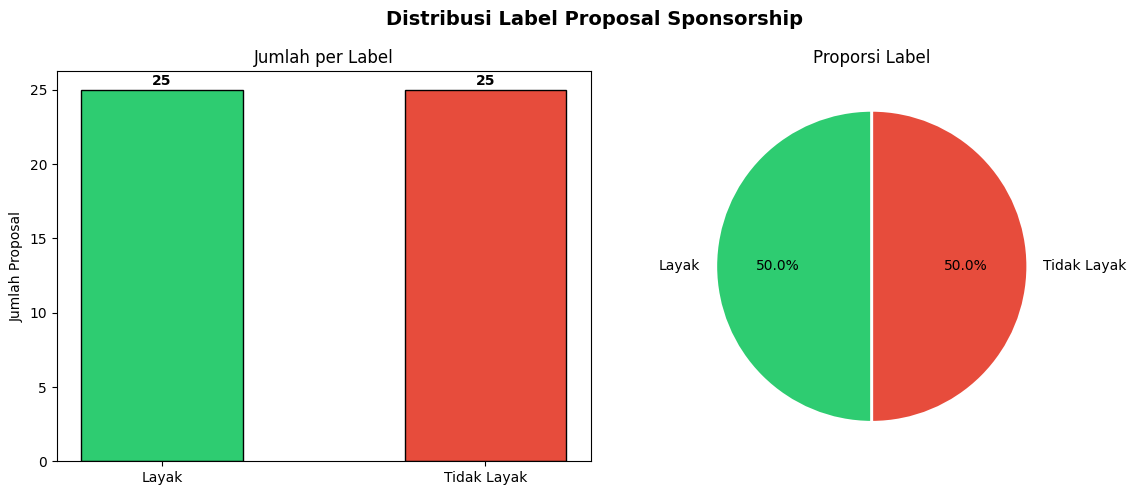

In [12]:
# CELL 5.2 — Visualisasi 1: Distribusi Label

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Label Proposal Sponsorship', fontsize=14, fontweight='bold')

# Bar chart
colors  = ['#2ecc71', '#e74c3c']
counts  = df_eda['label_final'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Jumlah per Label')
axes[0].set_ylabel('Jumlah Proposal')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Label')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_01_distribusi_label.png'), dpi=150, bbox_inches='tight')
plt.show()

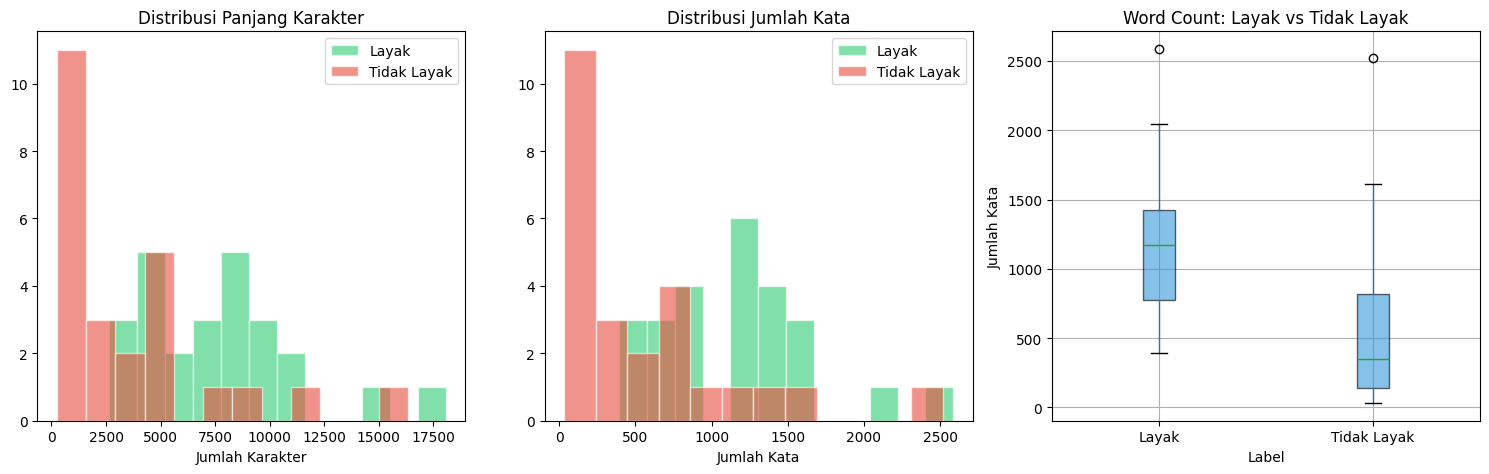

=== Statistik Panjang Teks ===
             count    mean    std    min    25%     50%     75%     max
label_final                                                            
Layak         25.0  1155.6  509.0  393.0  776.0  1175.0  1428.0  2586.0
Tidak Layak   25.0   559.2  601.9   32.0  138.0   352.0   819.0  2518.0


In [13]:
# CELL 5.3 — Visualisasi 2: Distribusi Panjang Teks

df_eda['text_length'] = df_eda['cleaned_text_svm'].str.len()
df_eda['word_count_clean'] = df_eda['cleaned_text_svm'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Panjang Teks per Label', fontsize=14, fontweight='bold')

# Histogram panjang karakter
for label, color in zip(['Layak', 'Tidak Layak'], ['#2ecc71', '#e74c3c']):
    subset = df_eda[df_eda['label_final'] == label]['text_length']
    axes[0].hist(subset, bins=12, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Distribusi Panjang Karakter')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].legend()

# Histogram word count
for label, color in zip(['Layak', 'Tidak Layak'], ['#2ecc71', '#e74c3c']):
    subset = df_eda[df_eda['label_final'] == label]['word_count_clean']
    axes[1].hist(subset, bins=12, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Distribusi Jumlah Kata')
axes[1].set_xlabel('Jumlah Kata')
axes[1].legend()

# Boxplot perbandingan
df_eda.boxplot(column='word_count_clean', by='label_final', ax=axes[2],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[2].set_title('Word Count: Layak vs Tidak Layak')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Jumlah Kata')
plt.suptitle('')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_02_distribusi_teks.png'), dpi=150, bbox_inches='tight')
plt.show()

# Statistik deskriptif
print("=== Statistik Panjang Teks ===")
print(df_eda.groupby('label_final')['word_count_clean'].describe().round(1))

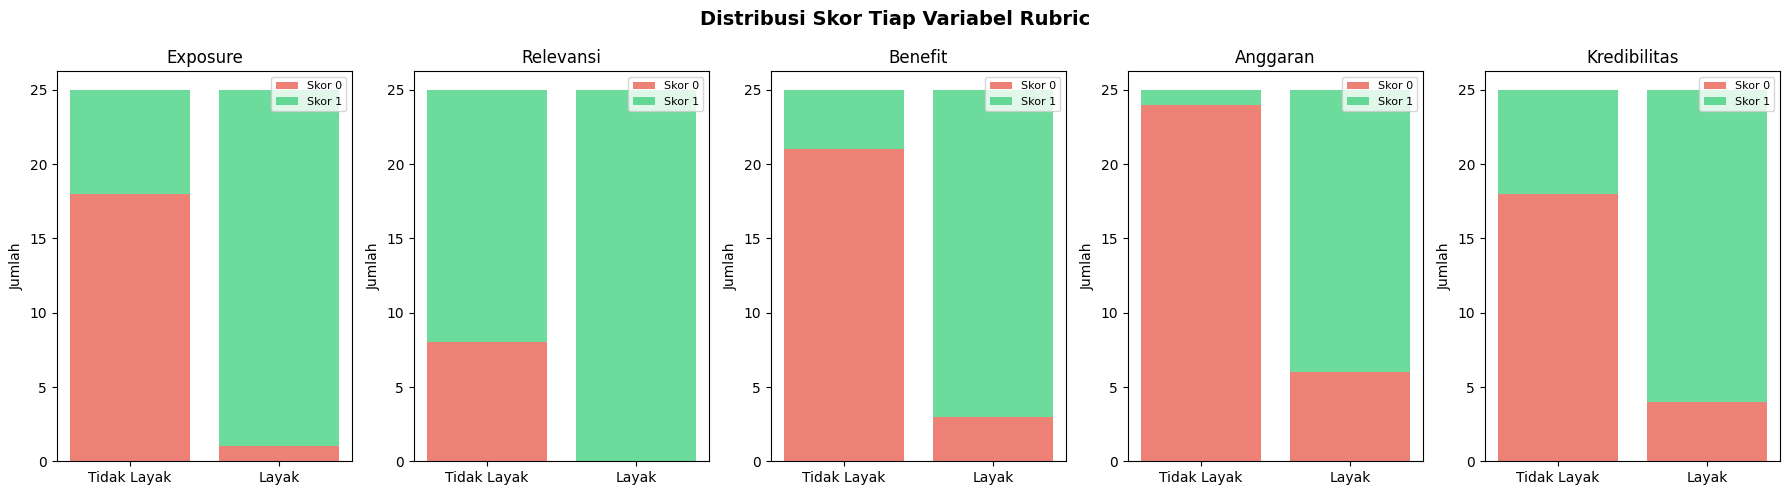

In [14]:
# CELL 5.4 — Visualisasi 3: Distribusi Skor per Variabel
rubric_vars = ['label_exposure','label_relevansi','label_benefit',
               'label_anggaran','label_kredibilitas']
var_labels  = ['Exposure','Relevansi','Benefit','Anggaran','Kredibilitas']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Distribusi Skor Tiap Variabel Rubric', fontsize=14, fontweight='bold')

for i, (var, label) in enumerate(zip(rubric_vars, var_labels)):
    counts_0 = df_eda[df_eda[var] == 0]['label_final'].value_counts()
    counts_1 = df_eda[df_eda[var] == 1]['label_final'].value_counts()

    x    = ['Tidak Layak', 'Layak']
    val0 = [counts_0.get('Tidak Layak', 0), counts_0.get('Layak', 0)]
    val1 = [counts_1.get('Tidak Layak', 0), counts_1.get('Layak', 0)]

    axes[i].bar(x, val0, label='Skor 0', color='#e74c3c', alpha=0.7)
    axes[i].bar(x, val1, bottom=val0, label='Skor 1', color='#2ecc71', alpha=0.7)
    axes[i].set_title(label)
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_03_skor_variabel.png'), dpi=150, bbox_inches='tight')
plt.show()

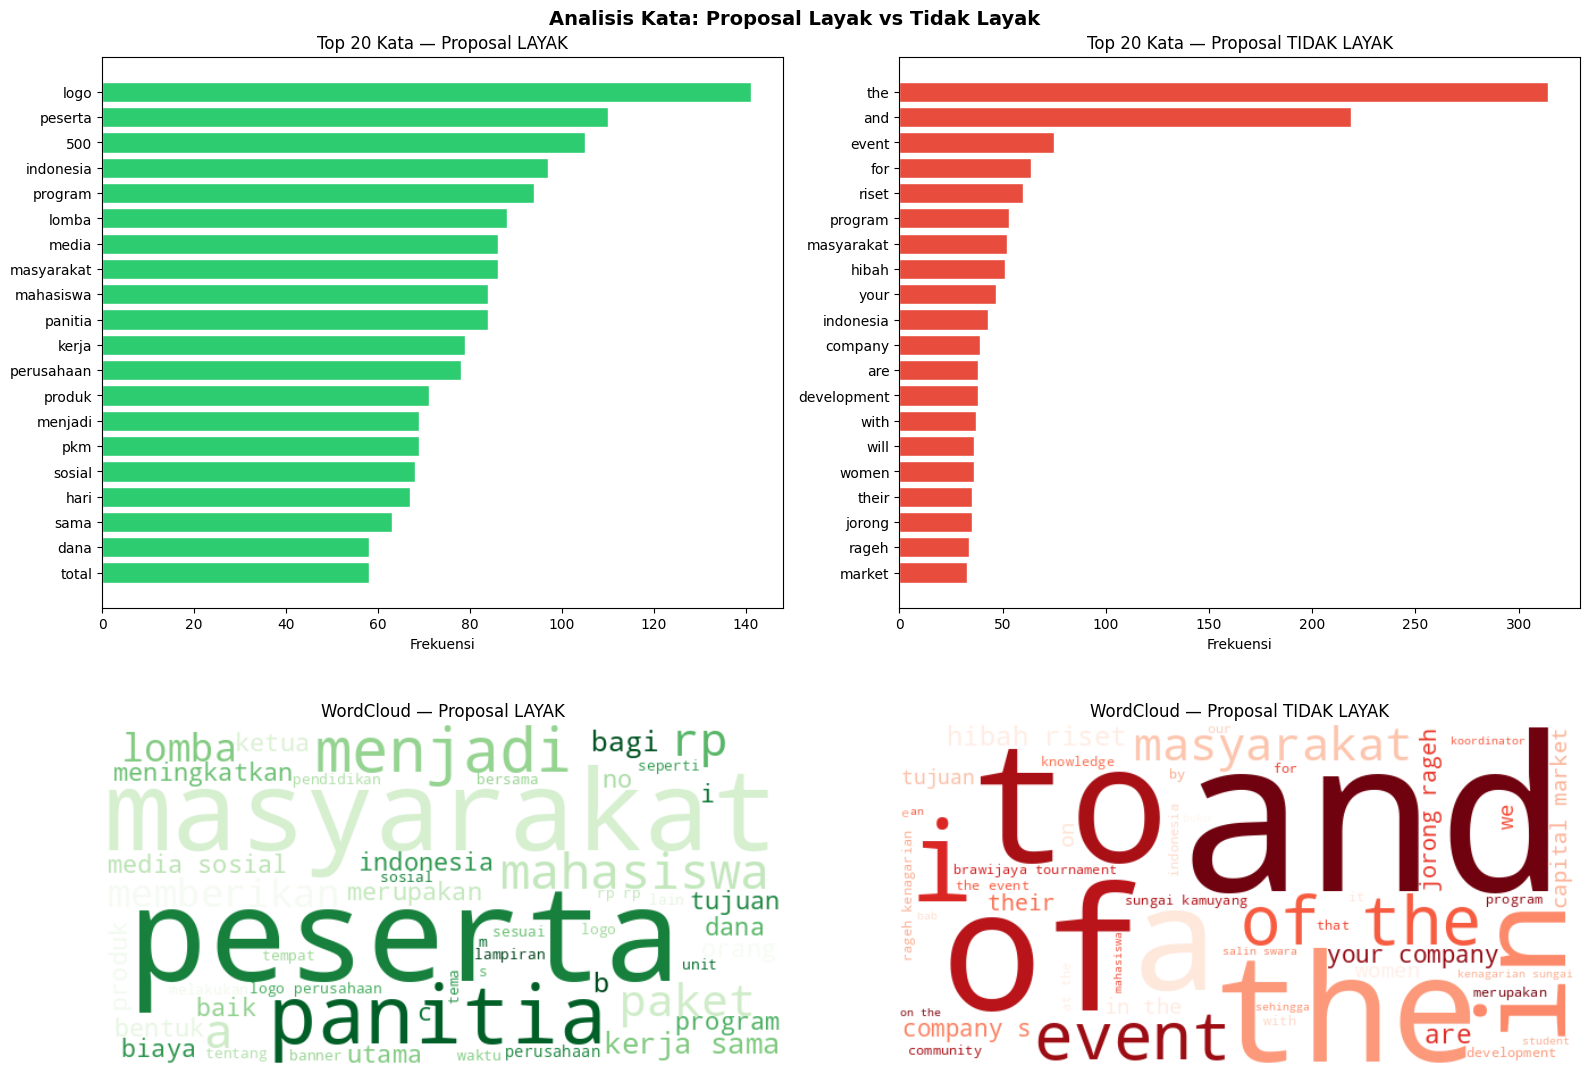

In [15]:
# CELL 5.5 — Visualisasi 4: Word Frequency & WordCloud
from collections import Counter

# Stopword bahasa Indonesia (ringkas — bisa diperluas)
STOPWORDS_ID = set([
    'yang','dan','di','ke','dari','untuk','dengan','ini','itu','atau',
    'adalah','pada','dalam','tidak','akan','juga','sebagai','oleh',
    'dapat','telah','ada','kami','kita','mereka','saya','anda','bisa',
    'lebih','sudah','setelah','serta','acara','kegiatan','proposal',
    'sponsorship','sponsor','para','pihak','hal','cara','setiap',
    'berbagai','tersebut','yaitu','antara','karena','namun','saat',
    'melalui','kepada','bahwa','sangat','tahun','maka','agar','demi',
])

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = [w for w in str(text).split() if w not in STOPWORDS_ID and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

layak_texts  = df_eda[df_eda['label_final'] == 'Layak']['cleaned_text_svm']
tidak_texts  = df_eda[df_eda['label_final'] == 'Tidak Layak']['cleaned_text_svm']

top_layak  = get_top_words(layak_texts)
top_tidak  = get_top_words(tidak_texts)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisis Kata: Proposal Layak vs Tidak Layak',
             fontsize=14, fontweight='bold')

# Bar chart — Layak
words_l, counts_l = zip(*top_layak)
axes[0,0].barh(words_l[::-1], counts_l[::-1], color='#2ecc71', edgecolor='white')
axes[0,0].set_title('Top 20 Kata — Proposal LAYAK')
axes[0,0].set_xlabel('Frekuensi')

# Bar chart — Tidak Layak
words_t, counts_t = zip(*top_tidak)
axes[0,1].barh(words_t[::-1], counts_t[::-1], color='#e74c3c', edgecolor='white')
axes[0,1].set_title('Top 20 Kata — Proposal TIDAK LAYAK')
axes[0,1].set_xlabel('Frekuensi')

# WordCloud — Layak
wc_layak = WordCloud(width=600, height=300, background_color='white',
                     stopwords=STOPWORDS_ID, colormap='Greens',
                     max_words=50).generate(' '.join(layak_texts))
axes[1,0].imshow(wc_layak, interpolation='bilinear')
axes[1,0].axis('off')
axes[1,0].set_title('WordCloud — Proposal LAYAK')

# WordCloud — Tidak Layak
wc_tidak = WordCloud(width=600, height=300, background_color='white',
                     stopwords=STOPWORDS_ID, colormap='Reds',
                     max_words=50).generate(' '.join(tidak_texts))
axes[1,1].imshow(wc_tidak, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('WordCloud — Proposal TIDAK LAYAK')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_04_word_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

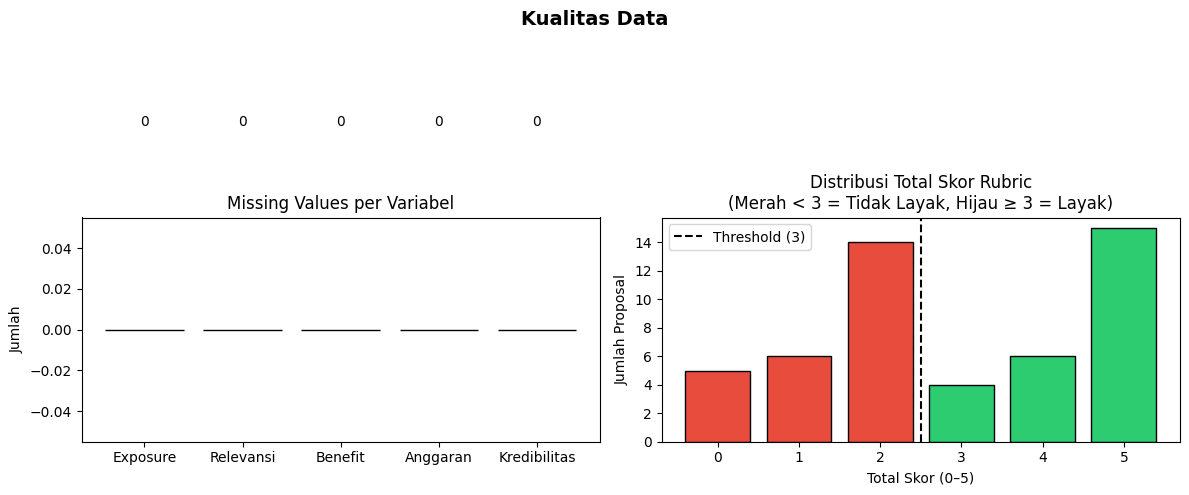


=== INSIGHT EDA ===
Proposal Layak     : 163 (80.7%)
Proposal Tdk Layak : 39 (19.3%)
Rata-rata skor     : 3.75 / 5
Variabel paling banyak skor 0: label_anggaran
Variabel paling banyak skor 1: label_relevansi


In [16]:
# CELL 5.6 — Visualisasi 5: Missing Value & Data Quality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Kualitas Data', fontsize=14, fontweight='bold')

# Missing value
missing = df_final[rubric_vars].isnull().sum()
axes[0].bar(var_labels, missing.values, color='#e67e22', edgecolor='black')
axes[0].set_title('Missing Values per Variabel')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(missing.values):
    axes[0].text(i, v + 0.1, str(v), ha='center')

# Distribusi total skor
skor_counts = df_eda['total_skor'].value_counts().sort_index()
colors_skor = ['#e74c3c' if s < 3 else '#2ecc71' for s in skor_counts.index]
axes[1].bar(skor_counts.index, skor_counts.values, color=colors_skor, edgecolor='black')
axes[1].set_title('Distribusi Total Skor Rubric\n(Merah < 3 = Tidak Layak, Hijau ≥ 3 = Layak)')
axes[1].set_xlabel('Total Skor (0–5)')
axes[1].set_ylabel('Jumlah Proposal')
axes[1].axvline(x=2.5, color='black', linestyle='--', label='Threshold (3)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_05_data_quality.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n=== INSIGHT EDA ===")
print(f"Proposal Layak     : {(df_final['label_final']=='Layak').sum()} ({(df_final['label_final']=='Layak').mean()*100:.1f}%)")
print(f"Proposal Tdk Layak : {(df_final['label_final']=='Tidak Layak').sum()} ({(df_final['label_final']=='Tidak Layak').mean()*100:.1f}%)")
print(f"Rata-rata skor     : {df_final['total_skor'].mean():.2f} / 5")
print(f"Variabel paling banyak skor 0: {df_final[rubric_vars].eq(0).sum().idxmax()}")
print(f"Variabel paling banyak skor 1: {df_final[rubric_vars].eq(1).sum().idxmax()}")

In [17]:
# CELL 6.1 — Stemming Bahasa Indonesia (untuk SVM)

!pip install PySastrawi -q

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory_stem = StemmerFactory()
stemmer      = factory_stem.create_stemmer()

factory_stop = StopWordRemoverFactory()
stopword_rem = factory_stop.create_stop_word_remover()

def full_preprocess_svm(text: str) -> str:
    """
    Pipeline preprocessing lengkap untuk SVM + TF-IDF:
    1. Cleaning dasar
    2. Stopword removal (Sastrawi)
    3. Stemming (Sastrawi)
    """
    text = clean_for_svm(text)                 # lowercase + hapus simbol
    text = stopword_rem.remove(text)           # hapus stopword bahasa Indonesia
    text = stemmer.stem(text)                  # stemming
    return text

# Terapkan (perlu waktu beberapa menit untuk 200 dokumen)
print("Memulai preprocessing SVM... (bisa 3-5 menit)")
df_final['text_svm_processed'] = df_final['cleaned_text_svm'].apply(full_preprocess_svm)
print(" Preprocessing SVM selesai")

# Preview perbandingan sebelum vs sesudah
idx = df_final[df_final['status']=='success'].index[0]
print(f"\nSebelum: {df_final.loc[idx,'cleaned_text_svm'][:200]}")
print(f"\nSesudah: {df_final.loc[idx,'text_svm_processed'][:200]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 19.5 MB/s eta 0:00:00
Memulai preprocessing SVM... (bisa 3-5 menit)
 Preprocessing SVM selesai

Sebelum: rise 2025 by hima data science contents 03 introduction 05 profile timeline rise 07 rancangan anggaran 10 sponsorship package poin poin terkait 12 kerja sama 13 about us 14 gallery himpunan mahasiswa 

Sesudah: rise 2025 by hima data science contents 03 introduction 05 profile timeline rise 07 rancang anggar 10 sponsorship package poin poin kait 12 13 about us 14 gallery himpun mahasiswa data science himpun 


In [18]:
# CELL 6.2 — Train/Validation/Test Split

# Hanya pakai data yang punya label
df_model = df_final[df_final['label_final'].notna()].copy()
df_model = df_model[df_model['text_svm_processed'].str.len() > 10]

X = df_model['text_svm_processed'].values
y = df_model['label_final'].values

# 70% train | 15% val | 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Split dataset:")
print(f"  Train : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val   : {len(X_val)} ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nDistribusi label Train:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts): print(f"  {u}: {c}")

Split dataset:
  Train : 141 (70%)
  Val   : 30 (15%)
  Test  : 31 (15%)

Distribusi label Train:
  Layak: 114
  Tidak Layak: 27


In [19]:
# CELL 6.3 — Training SVM + TF-IDF

from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),    # unigram + bigram
        max_features=5000,
        sublinear_tf=True,     # log normalization TF
        min_df=2,              # abaikan kata yang muncul < 2 dokumen
        max_df=0.95,           # abaikan kata yang muncul di > 95% dokumen
    )),
    ('svm', SVC(
        kernel='linear',       # linear kernel terbaik untuk text classification
        C=1.0,
        probability=True,      # untuk confidence score
        random_state=SEED,
        class_weight='balanced' # handle imbalanced dataset
    ))
])

# Hyperparameter tuning dengan cross-validation
param_grid = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range' : [(1,1), (1,2)],
    'svm__C'             : [0.1, 1.0, 10.0],
}

print("Memulai GridSearch CV... (bisa 2-5 menit)")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    svm_pipeline, param_grid,
    cv=cv, scoring='f1_weighted',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_
print(f"\n Best params : {grid_search.best_params_}")
print(f"   Best CV F1  : {grid_search.best_score_:.4f}")

Memulai GridSearch CV... (bisa 2-5 menit)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

 Best params : {'svm__C': 1.0, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}
   Best CV F1  : 0.8680



EVALUASI SVM — Validation Set
Accuracy  : 0.8000
Precision : 0.7769
Recall    : 0.8000
F1-Score  : 0.7840

Classification Report:
              precision    recall  f1-score   support

       Layak       0.85      0.92      0.88        24
 Tidak Layak       0.50      0.33      0.40         6

    accuracy                           0.80        30
   macro avg       0.67      0.62      0.64        30
weighted avg       0.78      0.80      0.78        30



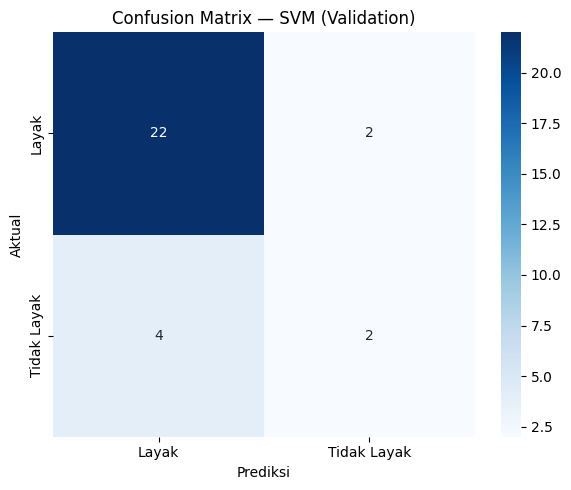


EVALUASI SVM — Test Set
Accuracy  : 0.8710
Precision : 0.8620
Recall    : 0.8710
F1-Score  : 0.8605

Classification Report:
              precision    recall  f1-score   support

       Layak       0.89      0.96      0.92        25
 Tidak Layak       0.75      0.50      0.60         6

    accuracy                           0.87        31
   macro avg       0.82      0.73      0.76        31
weighted avg       0.86      0.87      0.86        31



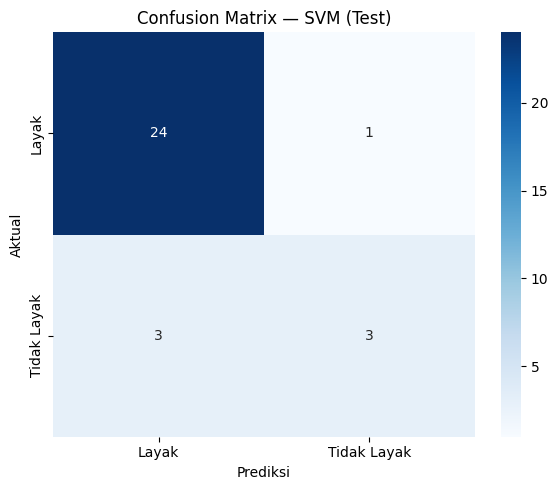

In [20]:
# CELL 6.4 — Evaluasi SVM

def evaluate_model(model, X, y, set_name="Test", model_name="Model"):
    y_pred = model.predict(X)
    acc    = accuracy_score(y, y_pred)
    prec   = precision_score(y, y_pred, average='weighted', zero_division=0)
    rec    = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1     = f1_score(y, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"EVALUASI {model_name} — {set_name} Set")
    print(f"{'='*50}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred, labels=['Layak','Tidak Layak'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Layak','Tidak Layak'],
                yticklabels=['Layak','Tidak Layak'])
    plt.title(f'Confusion Matrix — {model_name} ({set_name})')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'viz_cm_{model_name.lower().replace(" ","_")}_{set_name.lower()}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# Evaluasi di validation set dulu (untuk tuning)
svm_val_metrics  = evaluate_model(best_svm, X_val,  y_val,  "Validation", "SVM")
# Evaluasi final di test set
svm_test_metrics = evaluate_model(best_svm, X_test, y_test, "Test",       "SVM")

In [21]:
# CELL 7.1 — Setup IndoBERT

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN    = 256   # panjang token maksimum
BATCH_SIZE = 8
EPOCHS     = 5
LR         = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f" Tokenizer IndoBERT loaded: {MODEL_NAME}")

Device: cuda


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

 Tokenizer IndoBERT loaded: indobenchmark/indobert-base-p1


In [22]:
# CELL 7.2 — Dataset & DataLoader untuk IndoBERT

label2id = {"Layak": 1, "Tidak Layak": 0}
id2label = {0: "Tidak Layak", 1: "Layak"}

class ProposalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label'         : torch.tensor(label2id[self.labels[idx]], dtype=torch.long)
        }

# Pakai cleaned_text_bert (preprocessing minimal)
X_bert       = df_model['cleaned_text_bert'].values
y_bert       = df_model['label_final'].values

X_b_train, X_b_temp, y_b_train, y_b_temp = train_test_split(
    X_bert, y_bert, test_size=0.30, random_state=SEED, stratify=y_bert
)
X_b_val, X_b_test, y_b_val, y_b_test = train_test_split(
    X_b_temp, y_b_temp, test_size=0.50, random_state=SEED, stratify=y_b_temp
)

train_dataset = ProposalDataset(X_b_train, y_b_train, tokenizer_bert, MAX_LEN)
val_dataset   = ProposalDataset(X_b_val,   y_b_val,   tokenizer_bert, MAX_LEN)
test_dataset  = ProposalDataset(X_b_test,  y_b_test,  tokenizer_bert, MAX_LEN)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f" DataLoader siap")
print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

 DataLoader siap
   Train: 141 | Val: 30 | Test: 31


In [23]:
# CELL 7.3 — Fine-tuning IndoBERT

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
).to(DEVICE)

optimizer = AdamW(model_bert.parameters(), lr=LR, weight_decay=0.01)
total_steps     = len(train_loader) * EPOCHS
warmup_steps    = total_steps // 10
scheduler       = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds   = torch.argmax(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds   = torch.argmax(outputs.logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels

# Training loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_f1   = 0
best_model_path = os.path.join(OUTPUT_DIR, "best_indobert_model")

print("Memulai fine-tuning IndoBERT...\n")
for epoch in range(EPOCHS):
    tr_loss, tr_acc                       = train_epoch(model_bert, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc, vl_preds, vl_labels = eval_epoch(model_bert, val_loader, DEVICE)

    vl_f1 = f1_score(vl_labels, vl_preds, average='weighted')
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} F1: {vl_f1:.4f}")

    # Simpan model terbaik berdasarkan val F1
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        model_bert.save_pretrained(best_model_path)
        tokenizer_bert.save_pretrained(best_model_path)
        print(f"  Model terbaik disimpan (Val F1: {best_val_f1:.4f})")

print(f"\nTraining selesai! Best Val F1: {best_val_f1:.4f}")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Memulai fine-tuning IndoBERT...

Epoch 1/5 | Train Loss: 0.5038 Acc: 0.8014 | Val Loss: 0.5587 Acc: 0.8000 F1: 0.7111


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model terbaik disimpan (Val F1: 0.7111)
Epoch 2/5 | Train Loss: 0.4435 Acc: 0.8085 | Val Loss: 0.5857 Acc: 0.8000 F1: 0.7111
Epoch 3/5 | Train Loss: 0.3845 Acc: 0.8156 | Val Loss: 0.5673 Acc: 0.7667 F1: 0.7346


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Model terbaik disimpan (Val F1: 0.7346)
Epoch 4/5 | Train Loss: 0.3040 Acc: 0.8511 | Val Loss: 0.7576 Acc: 0.6667 F1: 0.6832
Epoch 5/5 | Train Loss: 0.2633 Acc: 0.8865 | Val Loss: 0.7311 Acc: 0.7333 F1: 0.7333

Training selesai! Best Val F1: 0.7346


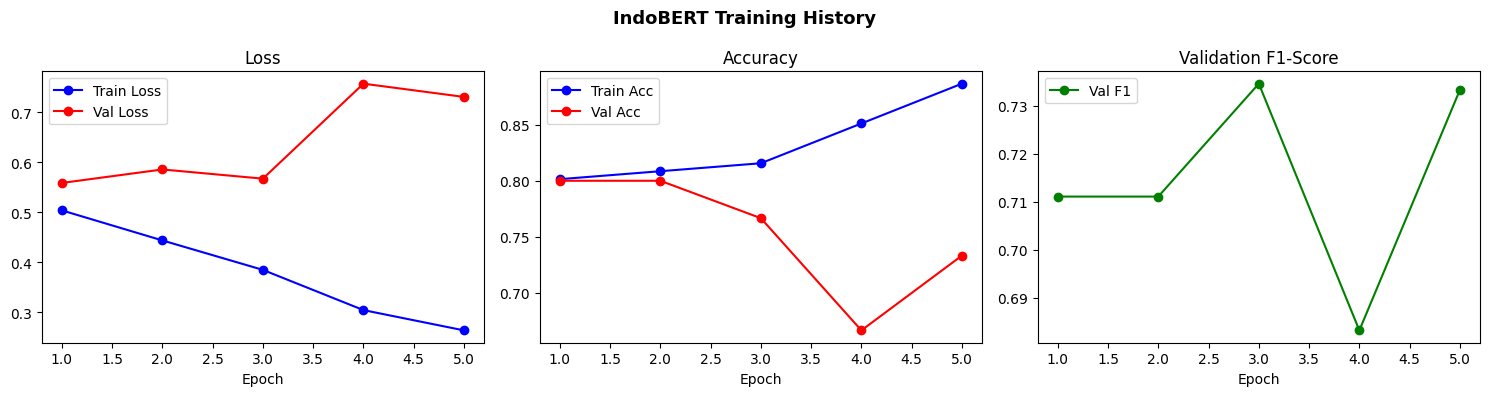

In [24]:
# CELL 7.4 — Visualisasi Training History

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('IndoBERT Training History', fontsize=13, fontweight='bold')
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_f1'], 'g-o', label='Val F1')
axes[2].set_title('Validation F1-Score'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_06_bert_training.png'), dpi=150, bbox_inches='tight')
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== EVALUASI IndoBERT — Test Set ===
  Accuracy  : 0.8065
  Precision : 0.7642
  Recall    : 0.8065
  F1        : 0.7652

Classification Report:
              precision    recall  f1-score   support

       Layak       0.83      0.96      0.89        25
 Tidak Layak       0.50      0.17      0.25         6

    accuracy                           0.81        31
   macro avg       0.66      0.56      0.57        31
weighted avg       0.76      0.81      0.77        31



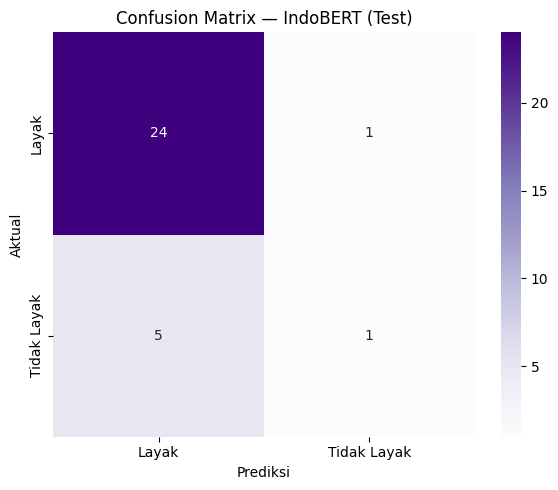

In [25]:
# CELL 7.5 — Evaluasi IndoBERT di Test Set

# Load model terbaik
best_bert = AutoModelForSequenceClassification.from_pretrained(best_model_path).to(DEVICE)

_, _, test_preds, test_labels = eval_epoch(best_bert, test_loader, DEVICE)

test_preds_str  = [id2label[p] for p in test_preds]
test_labels_str = [id2label[l] for l in test_labels]

bert_test_metrics = {
    'accuracy' : accuracy_score(test_labels_str, test_preds_str),
    'precision': precision_score(test_labels_str, test_preds_str, average='weighted', zero_division=0),
    'recall'   : recall_score(test_labels_str, test_preds_str, average='weighted', zero_division=0),
    'f1'       : f1_score(test_labels_str, test_preds_str, average='weighted', zero_division=0),
}

print("=== EVALUASI IndoBERT — Test Set ===")
for k, v in bert_test_metrics.items():
    print(f"  {k.capitalize():10}: {v:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_labels_str, test_preds_str))

# Confusion Matrix
cm_bert = confusion_matrix(test_labels_str, test_preds_str, labels=['Layak','Tidak Layak'])
plt.figure(figsize=(6,5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Layak','Tidak Layak'],
            yticklabels=['Layak','Tidak Layak'])
plt.title('Confusion Matrix — IndoBERT (Test)')
plt.ylabel('Aktual'); plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_cm_indobert_test.png'), dpi=150, bbox_inches='tight')
plt.show()

=== PERBANDINGAN MODEL ===
   Metric      SVM  IndoBERT
 Accuracy 0.870968  0.806452
Precision 0.862007  0.764182
   Recall 0.870968  0.806452
 F1-Score 0.860546  0.765233


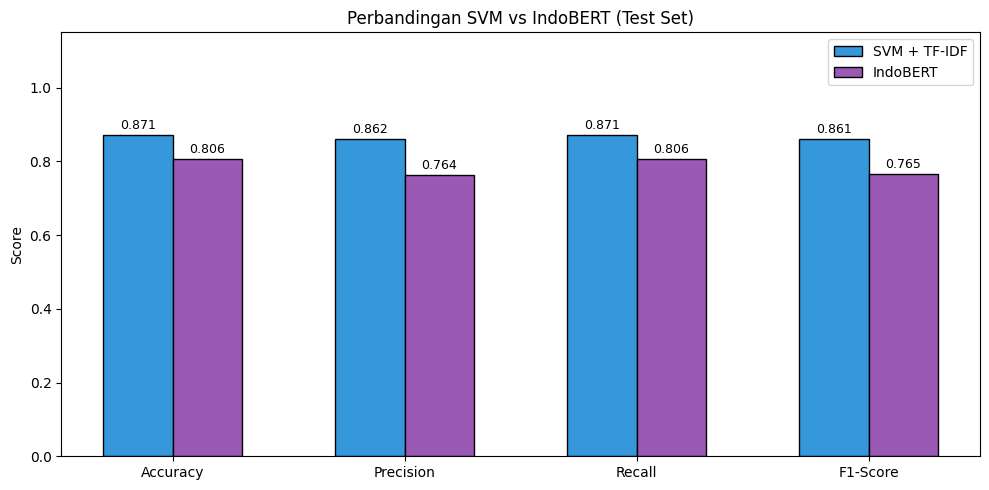


 Model Terbaik: SVM
   (Berdasarkan F1-Score: SVM=0.8605 | IndoBERT=0.7652)


In [26]:
# CELL 8.1 — Tabel & Chart Perbandingan SVM vs IndoBERT

comparison = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'SVM'      : [svm_test_metrics['accuracy'],  svm_test_metrics['precision'],
                  svm_test_metrics['recall'],     svm_test_metrics['f1']],
    'IndoBERT' : [bert_test_metrics['accuracy'],  bert_test_metrics['precision'],
                  bert_test_metrics['recall'],     bert_test_metrics['f1']],
})

print("=== PERBANDINGAN MODEL ===")
print(comparison.to_string(index=False))

# Chart perbandingan
fig, ax = plt.subplots(figsize=(10, 5))
x  = np.arange(len(comparison['Metric']))
w  = 0.30
b1 = ax.bar(x - w/2, comparison['SVM'],      w, label='SVM + TF-IDF', color='#3498db', edgecolor='black')
b2 = ax.bar(x + w/2, comparison['IndoBERT'], w, label='IndoBERT',     color='#9b59b6', edgecolor='black')

ax.set_xticks(x); ax.set_xticklabels(comparison['Metric'])
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score'); ax.set_title('Perbandingan SVM vs IndoBERT (Test Set)')
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'viz_07_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Rekomendasi model
best_model_name = 'IndoBERT' if bert_test_metrics['f1'] > svm_test_metrics['f1'] else 'SVM'
print(f"\n Model Terbaik: {best_model_name}")
print(f"   (Berdasarkan F1-Score: SVM={svm_test_metrics['f1']:.4f} | "
      f"IndoBERT={bert_test_metrics['f1']:.4f})")

In [27]:
# ═══════════════════════════════════════════════════════
# CELL 9.1 — Tulis Streamlit App ke File (FIXED)
# ═══════════════════════════════════════════════════════
app_code = '''
import streamlit as st
import re, os, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pdfplumber
import pytesseract
from pdf2image import convert_from_path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pickle

st.set_page_config(
    page_title="SponsorSmart AI",
    page_icon="🎯",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
    .main-title {
        font-size: 2.5rem; font-weight: 800;
        background: linear-gradient(135deg, #667eea, #764ba2);
        -webkit-background-clip: text; -webkit-text-fill-color: transparent;
        text-align: center; margin-bottom: 0.5rem;
    }
    .subtitle { text-align: center; color: #666; margin-bottom: 2rem; }
    .metric-card {
        background: #f8f9fa; border-radius: 12px;
        padding: 1rem; text-align: center;
        border-left: 4px solid #667eea; margin-bottom: 0.5rem;
    }
    .layak-badge {
        background: #d4edda; color: #155724;
        padding: 0.8rem 2rem; border-radius: 25px;
        font-size: 1.4rem; font-weight: 700;
        display: inline-block; margin: 1rem 0;
    }
    .tidak-layak-badge {
        background: #f8d7da; color: #721c24;
        padding: 0.8rem 2rem; border-radius: 25px;
        font-size: 1.4rem; font-weight: 700;
        display: inline-block; margin: 1rem 0;
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<p class="main-title">🎯 SponsorSmart AI</p>', unsafe_allow_html=True)
st.markdown('<p class="subtitle">Sistem Pendukung Keputusan Penilaian Kelayakan Proposal Sponsorship</p>',
            unsafe_allow_html=True)
st.divider()

MODEL_PATH    = "./best_indobert_model"
SVM_PATH      = "./svm_model.pkl"
OCR_THRESHOLD = 50

RUBRIC_KEYWORDS = {
    "Exposure": [
        r"\\b\\d[\\d.]*\\s*(?:peserta|pengunjung|penonton|orang|hadirin)\\b",
        r"\\b(?:instagram|youtube|tiktok|facebook|twitter|linkedin)\\b",
        r"\\b(?:media sosial|live streaming|publikasi|promosi|liputan)\\b",
        r"\\b(?:followers|subscriber|views|reach|tayangan)\\b",
        r"\\b(?:poster|banner|flyer|spanduk|baliho|pamflet)\\b",
    ],
    "Relevansi": [
        r"\\b(?:teknologi|digital|startup|inovasi|bisnis|korporat)\\b",
        r"\\b(?:pendidikan|universitas|kampus|mahasiswa|akademis)\\b",
        r"\\b(?:olahraga|kesehatan|lifestyle|sport|atletik)\\b",
        r"\\b(?:seni|budaya|musik|festival|entertainment|hiburan)\\b",
        r"\\b(?:sesuai|relevan|sejalan|mendukung)\\s+(?:dengan|visi|misi|brand)\\b",
    ],
    "Benefit": [
        r"\\b(?:logo|branding|brand awareness|visibilitas)\\b",
        r"\\b(?:logo placement|official sponsor|title sponsor|presenting sponsor)\\b",
        r"\\b(?:booth|stand|pameran|aktivasi brand|exhibition)\\b",
        r"\\b(?:mention|endorse|konten sponsor|publikasi sponsor)\\b",
        r"\\b(?:tiket gratis|vip|akses eksklusif|goodie bag|merchandise)\\b",
    ],
    "Anggaran": [
        r"(?:rp|idr)\\.?\\s*[\\d.,]{6,15}",
        r"(?:anggaran|biaya|dana|investasi|kontribusi|nominal)\\s*[:=]?\\s*(?:rp)?[\\d.,]{6,15}",
        r"\\b(?:paket)\\s+(?:platinum|gold|silver|bronze|diamond)\\b",
        r"\\b(?:rab|rencana anggaran biaya|kebutuhan dana)\\b",
    ],
    "Kredibilitas": [
        r"\\b(?:himpunan|bem|osis|komunitas|lembaga|yayasan|pt\\.|cv\\.|organisasi)\\b",
        r"\\b(?:susunan panitia|struktur organisasi|divisi|sie)\\b",
        r"\\b(?:ketua|sekretaris|bendahara|koordinator|penanggung jawab)\\b",
        r"\\b(?:timeline|jadwal|rundown|susunan acara|agenda)\\b",
        r"\\b(?:contact person|cp|whatsapp|narahubung|email|telp)\\b",
    ]
}

THRESHOLDS = {
    "Exposure": 2, "Relevansi": 1, "Benefit": 2,
    "Anggaran": 1, "Kredibilitas": 3
}

SARAN = {
    "Exposure"    : "Tambahkan data audiens (jumlah peserta, jangkauan media sosial, platform publikasi).",
    "Relevansi"   : "Jelaskan keterkaitan acara dengan industri/brand sponsor secara eksplisit.",
    "Benefit"     : "Cantumkan benefit konkret: logo placement, booth, mention medsos, goodie bag, dll.",
    "Anggaran"    : "Sertakan nominal jelas (Rp) dan paket sponsorship (Gold/Silver/Bronze).",
    "Kredibilitas": "Lengkapi identitas organisasi, susunan panitia, timeline, rundown, dan kontak PIC.",
}

VAR_ICONS = {
    "Exposure":"📡", "Relevansi":"🎯", "Benefit":"🎁",
    "Anggaran":"💰", "Kredibilitas":"🏛️"
}

@st.cache_resource
def load_bert_model():
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
        model     = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
        model.eval()
        return tokenizer, model
    except:
        return None, None

@st.cache_resource
def load_svm_model():
    try:
        with open(SVM_PATH, "rb") as f:
            return pickle.load(f)
    except:
        return None

def extract_text(uploaded_file):
    import tempfile
    with tempfile.NamedTemporaryFile(delete=False, suffix=".pdf") as tmp:
        tmp.write(uploaded_file.read())
        tmp_path = tmp.name
    full_text = ""
    method    = "pdfplumber"
    try:
        with pdfplumber.open(tmp_path) as pdf:
            for page in pdf.pages[:10]:
                text = page.extract_text()
                if text:
                    full_text += text + "\\n"
    except:
        pass
    if len(full_text.strip()) < OCR_THRESHOLD:
        method = "ocr"
        try:
            images = convert_from_path(tmp_path, first_page=1, last_page=3)
            for img in images:
                full_text += pytesseract.image_to_string(img, lang="ind") + "\\n"
        except:
            full_text = ""
    os.unlink(tmp_path)
    return full_text.strip(), method

def score_rubric(text):
    text_lower = text.lower()
    scores, evidences = {}, {}
    for var, patterns in RUBRIC_KEYWORDS.items():
        matched = []
        for p in patterns:
            found = re.findall(p, text_lower, re.IGNORECASE)
            if found:
                matched.extend(found[:2])
        unique_matched = list(set(matched))
        scores[var]    = 1 if len(unique_matched) >= THRESHOLDS[var] else 0
        evidences[var] = unique_matched[:3] if unique_matched else []
    total = sum(scores.values())
    return {
        "scores"         : scores,
        "evidences"      : evidences,
        "total"          : total,
        "heuristic_label": "Layak" if total >= 3 else "Tidak Layak"
    }

def predict_bert(text, tokenizer, model):
    if tokenizer is None or model is None:
        return {"label": None, "confidence": None, "prob_layak": 0, "prob_tidak": 0}
    inputs = tokenizer(
        text, max_length=256, padding="max_length",
        truncation=True, return_tensors="pt"
    )
    with torch.no_grad():
        outputs = model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1).squeeze().tolist()
    label_idx  = int(torch.argmax(outputs.logits))
    labels_map = {0: "Tidak Layak", 1: "Layak"}
    return {
        "label"     : labels_map[label_idx],
        "confidence": max(probs),
        "prob_layak": probs[1],
        "prob_tidak": probs[0]
    }

def render_score_chart(scores):
    vars_  = list(scores.keys())
    vals   = list(scores.values())
    colors = ["#2ecc71" if v == 1 else "#e74c3c" for v in vals]
    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(vars_, vals, color=colors, edgecolor="white", height=0.5)
    ax.set_xlim(0, 1.5)
    ax.set_xlabel("Skor (0 = Tidak Terpenuhi, 1 = Terpenuhi)")
    ax.set_title("Skor Tiap Variabel Rubric")
    for bar, val in zip(bars, vals):
        lbl = "✓ Terpenuhi" if val == 1 else "✗ Tidak"
        ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                lbl, va="center", fontsize=10, fontweight="bold")
    green = mpatches.Patch(color="#2ecc71", label="Terpenuhi (1)")
    red   = mpatches.Patch(color="#e74c3c", label="Tidak Terpenuhi (0)")
    ax.legend(handles=[green, red], loc="lower right")
    plt.tight_layout()
    return fig

# ── Sidebar ──────────────────────────────────────────
with st.sidebar:
    st.image("https://img.icons8.com/color/96/000000/target.png", width=80)
    st.title("⚙️ Pengaturan")
    model_choice = st.radio(
        "Pilih Model Prediksi:",
        ["IndoBERT (Rekomendasi)", "SVM + TF-IDF", "Keduanya (Bandingkan)"]
    )
    st.divider()
    st.markdown("### 📖 Tentang SponsorSmart AI")
    st.markdown("""
    Sistem ini membantu menilai kelayakan proposal sponsorship
    berdasarkan **5 variabel rubric**:
    - 📡 **Exposure** — Jangkauan audiens
    - 🎯 **Relevansi** — Kesesuaian dengan sponsor
    - 🎁 **Benefit** — Keuntungan sponsor
    - 💰 **Anggaran** — Kejelasan biaya
    - 🏛️ **Kredibilitas** — Profesionalitas penyelenggara

    **Label:** Total Skor ≥ 3 → **Layak**
    """)

# ── Main ─────────────────────────────────────────────
st.subheader("📤 Upload Proposal Sponsorship")
uploaded_file = st.file_uploader(
    "Upload file PDF proposal sponsorship",
    type=["pdf"],
    help="Format PDF, maksimal 50MB"
)

if uploaded_file is not None:
    st.success(f"✅ File berhasil diupload: **{uploaded_file.name}**")

    with st.spinner("🔍 Mengekstrak teks dari PDF..."):
        full_text, method = extract_text(uploaded_file)

    col1, col2 = st.columns([2, 1])
    with col1:
        with st.expander("👁️ Preview Teks Hasil Ekstraksi", expanded=False):
            if full_text:
                preview = full_text[:2000] + "..." if len(full_text) > 2000 else full_text
                st.text_area("Teks Proposal:", preview, height=250)
            else:
                st.error("Teks tidak dapat diekstrak dari file ini.")
    with col2:
        st.metric("Metode Ekstraksi", method.upper())
        st.metric("Jumlah Kata",      len(full_text.split()))
        st.metric("Jumlah Karakter",  len(full_text))

    if not full_text or len(full_text.split()) < 30:
        st.error("⚠️ Teks proposal terlalu sedikit untuk dianalisis.")
        st.stop()

    st.divider()

    if st.button("🚀 Analisis Proposal", type="primary", use_container_width=True):
        st.divider()
        st.subheader("📊 Hasil Analisis")

        with st.spinner("📋 Menghitung skor rubric..."):
            rubric_result = score_rubric(full_text)

        st.markdown("#### 📋 Skor Tiap Variabel Rubric")
        cols = st.columns(5)
        for i, (var, score) in enumerate(rubric_result["scores"].items()):
            with cols[i]:
                color  = "#d4edda" if score == 1 else "#f8d7da"
                status = "✓" if score == 1 else "✗"
                st.markdown(f"""
                <div style="background:{color};padding:12px;border-radius:10px;text-align:center;">
                    <div style="font-size:1.5rem">{VAR_ICONS[var]}</div>
                    <div style="font-weight:bold;font-size:0.9rem">{var}</div>
                    <div style="font-size:1.8rem;font-weight:800">{status}</div>
                    <div style="font-size:0.8rem">Skor: {score}/1</div>
                </div>
                """, unsafe_allow_html=True)

        st.pyplot(render_score_chart(rubric_result["scores"]))
        st.markdown(f"**Total Skor Rubric: {rubric_result[chr(39)+'total'+chr(39)]}/5**")

        with st.expander("🔍 Detail Bukti per Variabel"):
            for var, evid in rubric_result["evidences"].items():
                icon = "✅" if rubric_result["scores"][var] == 1 else "❌"
                st.markdown(f"{icon} **{var}**: {evid if evid else 'Tidak ditemukan indikator'}")

        st.divider()

        # ── Prediksi Model ────────────────────────────
        st.markdown("#### 🤖 Prediksi Model")

        # ✅ FIX: Inisialisasi variabel SEBELUM blok kondisi
        bert_result = {"label": None, "confidence": None, "prob_layak": 0, "prob_tidak": 0}
        svm_label   = None
        svm_conf    = 0

        bert_col, svm_col = st.columns(2)

        if model_choice in ["IndoBERT (Rekomendasi)", "Keduanya (Bandingkan)"]:
            with bert_col:
                with st.spinner("🧠 Prediksi IndoBERT..."):
                    tokenizer, bert_model = load_bert_model()
                    bert_result = predict_bert(full_text, tokenizer, bert_model)
                if bert_result["label"]:
                    badge = "layak-badge" if bert_result["label"] == "Layak" else "tidak-layak-badge"
                    st.markdown("**IndoBERT:**")
                    st.markdown(f'<span class="{badge}">{bert_result["label"]}</span>',
                                unsafe_allow_html=True)
                    conf = int(bert_result["confidence"] * 100)
                    st.progress(conf)
                    st.caption(f"Confidence: {conf}%")
                    st.caption(
                        f"P(Layak)={bert_result[chr(39)+'prob_layak'+chr(39)]*100:.1f}% | "
                        f"P(Tidak Layak)={bert_result[chr(39)+'prob_tidak'+chr(39)]*100:.1f}%"
                    )
                else:
                    st.warning("Model IndoBERT tidak ditemukan. Pakai hasil rubric saja.")

        if model_choice in ["SVM + TF-IDF", "Keduanya (Bandingkan)"]:
            with svm_col:
                with st.spinner("⚙️ Prediksi SVM..."):
                    svm_model = load_svm_model()
                    if svm_model:
                        svm_label = svm_model.predict([full_text])[0]
                        svm_prob  = svm_model.predict_proba([full_text])[0]
                        svm_conf  = int(max(svm_prob) * 100)
                        badge = "layak-badge" if svm_label == "Layak" else "tidak-layak-badge"
                        st.markdown("**SVM + TF-IDF:**")
                        st.markdown(f'<span class="{badge}">{svm_label}</span>',
                                    unsafe_allow_html=True)
                        st.progress(svm_conf)
                        st.caption(f"Confidence: {svm_conf}%")
                    else:
                        st.warning("Model SVM tidak ditemukan.")

        st.divider()

        # ── Keputusan Final ───────────────────────────
        # ✅ FIX: Semua variabel sudah pasti terdefinisi
        st.markdown("#### ⚖️ Keputusan Final")

        if model_choice == "IndoBERT (Rekomendasi)":
            final_label = bert_result["label"] or rubric_result["heuristic_label"]
        elif model_choice == "SVM + TF-IDF":
            final_label = svm_label or rubric_result["heuristic_label"]
        else:
            final_label = (bert_result["label"] or svm_label or
                           rubric_result["heuristic_label"])

        badge_class = "layak-badge" if final_label == "Layak" else "tidak-layak-badge"
        label_text  = "✅ LAYAK" if final_label == "Layak" else "❌ TIDAK LAYAK"

        col_dec, col_reason = st.columns([1, 2])
        with col_dec:
            st.markdown(
                f'<div style="text-align:center"><span class="{badge_class}">{label_text}</span></div>',
                unsafe_allow_html=True
            )
        with col_reason:
            st.markdown("**Alasan Keputusan:**")
            terpenuhi       = [v for v, s in rubric_result["scores"].items() if s == 1]
            tidak_terpenuhi = [v for v, s in rubric_result["scores"].items() if s == 0]
            if terpenuhi:
                st.success(f"✅ Variabel terpenuhi: {', '.join(terpenuhi)}")
            if tidak_terpenuhi:
                st.error(f"❌ Variabel tidak terpenuhi: {', '.join(tidak_terpenuhi)}")
            if final_label == "Layak":
                st.info("💡 Proposal memenuhi minimal 3 dari 5 kriteria kelayakan sponsorship.")
            else:
                st.warning("💡 Proposal perlu diperkuat — kurang dari 3 kriteria terpenuhi.")

        if tidak_terpenuhi:
            with st.expander("💡 Saran Perbaikan Proposal"):
                for var in tidak_terpenuhi:
                    st.markdown(f"**{var}:** {SARAN.get(var, \'\')}")

else:
    st.info("👆 Upload file PDF proposal sponsorship untuk memulai analisis.")
    c1, c2, c3 = st.columns(3)
    with c1:
        st.markdown("""<div class="metric-card">
            <h2>📡</h2><b>Exposure</b><p>Jangkauan audiens & media</p>
        </div>""", unsafe_allow_html=True)
    with c2:
        st.markdown("""<div class="metric-card">
            <h2>🎁</h2><b>Benefit</b><p>Keuntungan nyata untuk sponsor</p>
        </div>""", unsafe_allow_html=True)
    with c3:
        st.markdown("""<div class="metric-card">
            <h2>🏛️</h2><b>Kredibilitas</b><p>Profesionalitas penyelenggara</p>
        </div>""", unsafe_allow_html=True)
'''

with open("sponsorsmart_app.py", "w") as f:
    f.write(app_code)

print("✅ sponsorsmart_app.py (FIXED) berhasil ditulis!")


✅ File sponsorsmart_app.py berhasil dibuat


In [28]:
# CELL 9.2 — Simpan Model SVM (untuk dipakai di Streamlit)
import pickle

svm_output_path = os.path.join(OUTPUT_DIR, "svm_model.pkl")
with open(svm_output_path, "wb") as f:
    pickle.dump(best_svm, f)

print(f" Model SVM tersimpan: {svm_output_path}")
print(f" Model IndoBERT tersimpan: {best_model_path}")

 Model SVM tersimpan: /content/drive/MyDrive/dataset/sponsorsmart_output/svm_model.pkl
 Model IndoBERT tersimpan: /content/drive/MyDrive/dataset/sponsorsmart_output/best_indobert_model


In [29]:
!pip install streamlit pyngrok -q

from pyngrok import conf, ngrok

#  authtoken
ngrok.set_auth_token('3Da2fqdyH3xKXCvXZrAQ42pWf4N_6K4eV8DbdcqypQ7HDAoML')

# Jalankan streamlit di background
!nohup streamlit run sponsorsmart_app.py \
    --server.port 8501 \
    --server.headless true \
    --browser.gatherUsageStats false &> /content/streamlit.log &

import time; time.sleep(3)

# Buat public URL via ngrok
public_url = ngrok.connect(8501)
print(f"\n SponsorSmart AI berjalan di:")
print(f"   {public_url}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 127.3 MB/s eta 0:00:00

 SponsorSmart AI berjalan di:
   NgrokTunnel: "https://praising-twitter-flaxseed.ngrok-free.dev" -> "http://localhost:8501"
